In [1]:
import os
from collections import defaultdict

# ===== Change this to your slices output folder =====
output_dir = r"D:\PD_1YEAR\PPMI_split_slices"
# ====================================================

class_counts = defaultdict(int)

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg')):
            # Class name is the parent folder (AD, CN, MCI)
            class_name = os.path.basename(os.path.dirname(root))
            class_counts[class_name] += 1

print("📊 Slices per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


📊 Slices per class:
test: 520
train: 3980
val: 480


In [3]:
import os
from collections import defaultdict

# ===== Change this to your slices output folder =====
output_dir = r"D:\PD_1YEAR\PPMI_split_slices"
# ====================================================

# Dictionary: {split: {class: count}}
split_class_counts = defaultdict(lambda: defaultdict(int))

for split in os.listdir(output_dir):  # train, val, test
    split_path = os.path.join(output_dir, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):  # AD, CN, MCI
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        count = sum(1 for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg')))
        split_class_counts[split][cls] = count

# Print results
print("📊 Slices per class per split:\n")
for split in split_class_counts:
    print(f"--- {split.upper()} ---")
    for cls, count in split_class_counts[split].items():
        print(f"{cls}: {count}")
    print()


📊 Slices per class per split:

--- TEST ---
Control: 120
PD: 330
Prodromal: 70

--- TRAIN ---
Control: 960
PD: 2550
Prodromal: 470

--- VAL ---
Control: 120
PD: 310
Prodromal: 50



📊 Slices per class per split:

--- TRAIN ---
PD: 2550
Control: 960
Prodromal: 470

--- VAL ---
PD: 310
Control: 120
Prodromal: 50

--- TEST ---
PD: 330
Control: 120
Prodromal: 70

TOTAL PER CLASS:
PD: 3190
Control: 1200
Prodromal: 590


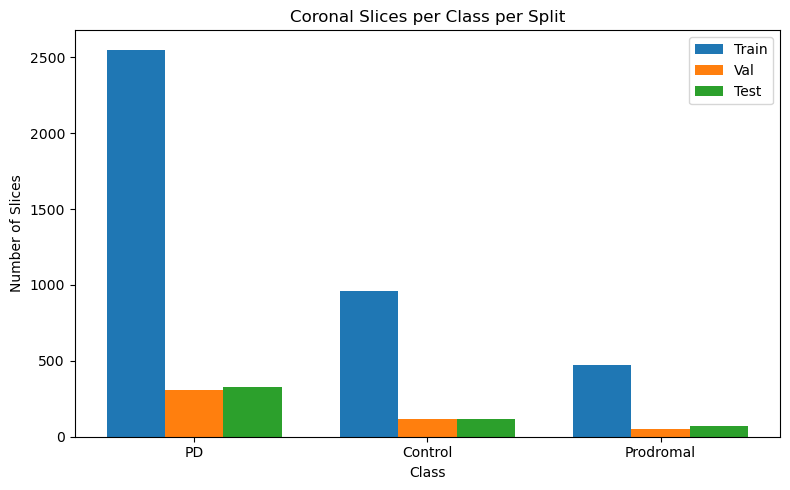


📌 Class Weights for PyTorch:
PD: 0.5204
Control: 1.3833
Prodromal: 2.8136

Class Weights Tensor: tensor([0.5204, 1.3833, 2.8136])


In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ============================
# CONFIGURATION
# ============================
slices_root = r"D:\PD_1YEAR\PPMI_split_slices"  # Path to extracted slices
splits = ["train", "val", "test"]
classes = ["PD", "Control", "Prodromal"]

# ============================
# STEP 1 — Count slices
# ============================
slice_counts = {split: {cls: 0 for cls in classes} for split in splits}

for split in splits:
    for cls in classes:
        folder = os.path.join(slices_root, split, cls)
        count = len([f for f in os.listdir(folder) if f.lower().endswith(".png")])
        slice_counts[split][cls] = count

# ============================
# STEP 2 — Display counts
# ============================
print("📊 Slices per class per split:\n")
total_per_class = {cls: 0 for cls in classes}

for split in splits:
    print(f"--- {split.upper()} ---")
    for cls in classes:
        count = slice_counts[split][cls]
        total_per_class[cls] += count
        print(f"{cls}: {count}")
    print()

print("TOTAL PER CLASS:")
for cls, total in total_per_class.items():
    print(f"{cls}: {total}")

# ============================
# STEP 3 — Plot bar chart
# ============================
x = np.arange(len(classes))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, split in enumerate(splits):
    counts = [slice_counts[split][cls] for cls in classes]
    ax.bar(x + i*bar_width, counts, width=bar_width, label=split.capitalize())

ax.set_xlabel("Class")
ax.set_ylabel("Number of Slices")
ax.set_title("Coronal Slices per Class per Split")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(classes)
ax.legend()
plt.tight_layout()
plt.show()

# ============================
# STEP 4 — Compute class weights (for PyTorch)
# ============================
total_slices = sum(total_per_class.values())
class_weights = {cls: total_slices / (len(classes) * total) for cls, total in total_per_class.items()}

print("\n📌 Class Weights for PyTorch:")
for cls, weight in class_weights.items():
    print(f"{cls}: {weight:.4f}")

# As a tensor for PyTorch:
import torch
class_weights_tensor = torch.tensor([class_weights[cls] for cls in classes], dtype=torch.float)
print("\nClass Weights Tensor:", class_weights_tensor)


In [5]:
import os
import torch

# Path to your coronal slices dataset
dataset_path = r"D:\PD_1YEAR\PPMI_split_slices"

# Classes (ensure they are in the same order you'll use for training)
classes = ['PD', 'Control', 'Prodromal']

slice_counts = {cls: 0 for cls in classes}

# Loop through each split (train, val, test)
for split in ['train', 'val', 'test']:
    for cls in classes:
        cls_dir = os.path.join(dataset_path, split, cls)
        if os.path.exists(cls_dir):
            slice_counts[cls] += len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print("📊 Slice counts per class:", slice_counts)

# Compute class weights
total_slices = sum(slice_counts.values())
num_classes = len(classes)
class_weights = [total_slices / (num_classes * slice_counts[cls]) for cls in classes]

print("\n📌 Class Weights for PyTorch:")
for cls, w in zip(classes, class_weights):
    print(f"{cls}: {w:.4f}")

weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print("\nClass Weights Tensor:", weights_tensor)


📊 Slice counts per class: {'PD': 3190, 'Control': 1200, 'Prodromal': 590}

📌 Class Weights for PyTorch:
PD: 0.5204
Control: 1.3833
Prodromal: 2.8136

Class Weights Tensor: tensor([0.5204, 1.3833, 2.8136])


In [6]:
import os
from collections import Counter
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ========= CONFIGURATION =========
data_dir = r"D:\PD_1YEAR\PPMI_split_slices"  # root dataset directory
batch_size = 6
image_size = (224, 224)  # resize target for model
num_workers = 4
# =================================

# Normalization values (ImageNet pretrained models)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# ----------- TRANSFORMS -----------
# Train: with augmentation
train_transforms = transforms.Compose([
    transforms.Resize(image_size),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(15),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Val/Test: no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# ----------- DATASETS -------------
train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "val"),
    transform=val_test_transforms
)
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    transform=val_test_transforms
)

# ----------- DATALOADERS ----------
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# ----------- CLASS NAMES ----------
print("Classes:", train_dataset.classes)
print(f"Train total: {len(train_dataset)}, Val total: {len(val_dataset)}, Test total: {len(test_dataset)}")

# ----------- COUNT PER CLASS -------
def count_per_class(dataset):
    counts = Counter()
    for _, label in dataset:
        counts[dataset.classes[label]] += 1
    return dict(counts)

print("\n📊 Slices per class per split:")
print("--- TRAIN ---", count_per_class(train_dataset))
print("--- VAL ---", count_per_class(val_dataset))
print("--- TEST ---", count_per_class(test_dataset))

# ----------- CLASS WEIGHTS ---------
all_counts = count_per_class(train_dataset)
total_train = sum(all_counts.values())
class_weights = [total_train / all_counts[cls] for cls in train_dataset.classes]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("\n📌 Class Weights for PyTorch:")
for cls, w in zip(train_dataset.classes, class_weights):
    print(f"{cls}: {w:.4f}")
print("Class Weights Tensor:", class_weights_tensor)


Classes: ['Control', 'PD', 'Prodromal']
Train total: 3980, Val total: 480, Test total: 520

📊 Slices per class per split:
--- TRAIN --- {'Control': 960, 'PD': 2550, 'Prodromal': 470}
--- VAL --- {'Control': 120, 'PD': 310, 'Prodromal': 50}
--- TEST --- {'Control': 120, 'PD': 330, 'Prodromal': 70}

📌 Class Weights for PyTorch:
Control: 4.1458
PD: 1.5608
Prodromal: 8.4681
Class Weights Tensor: tensor([4.1458, 1.5608, 8.4681])


In [8]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# =================== CONFIG ===================
data_dir = r"D:\PD_1YEAR\PPMI_split_slices"
batch_size = 8
image_size = (224, 224)
num_workers = 4
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class weights (example)
class_weights = torch.tensor([4.1458, 1.5608, 8.4681], dtype=torch.float).to(device)

# =================== STEP 1: Compute Mean & Std ===================
print("📊 Computing dataset mean and std...")
temp_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

train_dataset_for_stats = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=temp_transform)
train_loader_for_stats = DataLoader(train_dataset_for_stats, batch_size=batch_size, shuffle=False, num_workers=num_workers)

mean = 0.0
std = 0.0
nb_samples = 0

for data, _ in tqdm(train_loader_for_stats):
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)  # flatten H*W
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples

print(f"✅ Computed Mean: {mean}")
print(f"✅ Computed Std: {std}")

# =================== STEP 2: Define Transforms ===================
train_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

val_test_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# =================== STEP 3: Load Datasets ===================
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("Classes:", train_dataset.classes)

# =================== STEP 4: Model ===================
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# =================== STEP 5: Loss, Optimizer, Scheduler ===================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

# =================== STEP 6: Training Loop ===================
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=10):
    best_acc = 0.0
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in tqdm(loader):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                scheduler.step()

            # Save best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), "resedualnetwork50_finetuned_mri_PD.pth")
                print("✅ Best model saved.")

    print(f"\nTraining complete. Best val Acc: {best_acc:.4f}")
    return model

# =================== STEP 7: Train ===================
model = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs)


📊 Computing dataset mean and std...


100%|██████████| 498/498 [00:20<00:00, 24.76it/s] 


✅ Computed Mean: tensor([0.1600, 0.1600, 0.1600])
✅ Computed Std: tensor([0.2299, 0.2299, 0.2299])
Classes: ['Control', 'PD', 'Prodromal']

Epoch 1/10
------------------------------


100%|██████████| 498/498 [00:44<00:00, 11.26it/s]


train Loss: 0.9949 Acc: 0.5251


...

val Loss: 1.4248 Acc: 0.5750

Epoch 10/10
------------------------------


100%|██████████| 498/498 [00:44<00:00, 11.18it/s]


train Loss: 0.0353 Acc: 0.9937


100%|██████████| 60/60 [00:06<00:00,  9.34it/s]

val Loss: 1.5305 Acc: 0.5771

Training complete. Best val Acc: 0.5792
